In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [7]:
diabetes = pd.read_csv("diabetes.csv")
df = diabetes.copy()


In [8]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [9]:
df.shape

(768, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<Axes: xlabel='Pregnancies', ylabel='Count'>

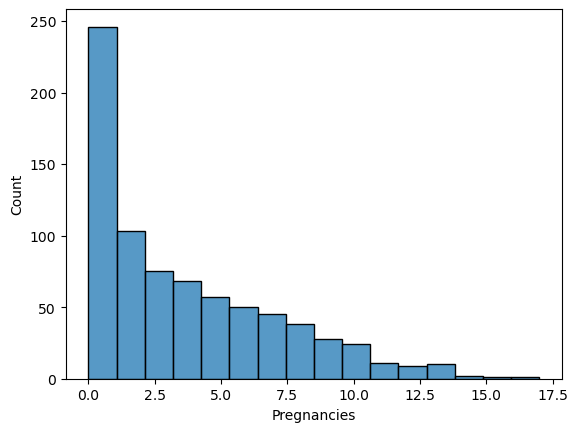

In [18]:
sns.histplot(data = df , x = "Pregnancies" )

In [20]:
x_train , x_test , y_train , y_test = train_test_split(x, y , test_size = 0.2 , random_state= 42 )

NameError: name 'x' is not defined

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Insulin'>

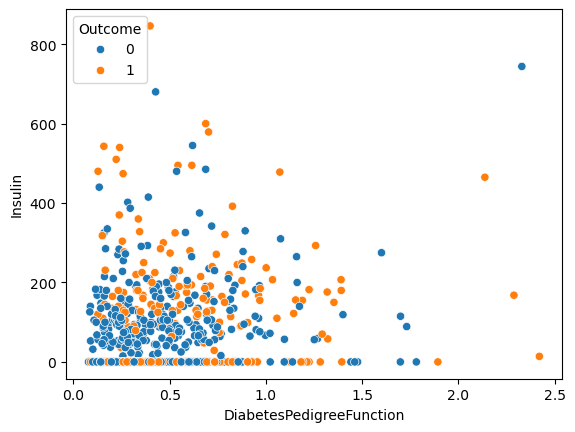

In [23]:
sns.scatterplot(data = df , x ="DiabetesPedigreeFunction" , y = "Insulin" , hue =  "Outcome")

In [25]:
x = df.drop("Outcome" , axis = 1)
y = df["Outcome"]

In [27]:
x_train , x_test , y_train , y_test = train_test_split(x , y ,test_size= 0.2 , random_state= 42)

In [39]:
df[df["Insulin"] == 0].count()

Pregnancies                 374
Glucose                     374
BloodPressure               374
SkinThickness               374
Insulin                     374
BMI                         374
DiabetesPedigreeFunction    374
Age                         374
Outcome                     374
dtype: int64

In [33]:
accuracy_score(y_test , y_predict)

0.7597402597402597

In [35]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81        99
           1       0.65      0.71      0.68        55

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



In [37]:
df["Pregnancies"] = df["Pregnancies"] > 1 

In [41]:
diabetic_insulin = (df[df["Outcome"] == 1]["Insulin"].mean()) 

In [43]:
un_diabetic_insulin = df[df["Outcome"] == 0]["Insulin"].mean()

In [45]:
diabetic_insulin

100.33582089552239

In [47]:
df.loc[(df["Outcome"]) == 1 & (df["Insulin"] == 0 ), "Insulin" ] = int(diabetic_insulin )

In [62]:
xgb_model = xgb.XGBRFClassifier().fit(x_train , y_train)

In [64]:
y_predict = xgb_model.predict(x_test)

In [76]:
models = {"XGBoost" : xgb.XGBClassifier() , "Logistic Regression" : LogisticRegression() , "Random Forest" : RandomForestClassifier()}

In [82]:
for name , model in models.items():
    model.fit(x_train , y_train)
    y_pred = model.predict(x_test)
    print("Model : " , name , "Accuarcy Score : ", accuracy_score(y_test , y_pred))

Model :  XGBoost Accuarcy Score :  0.7207792207792207
Model :  Logistic Regression Accuarcy Score :  0.7467532467532467
Model :  Random Forest Accuarcy Score :  0.7532467532467533


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: >

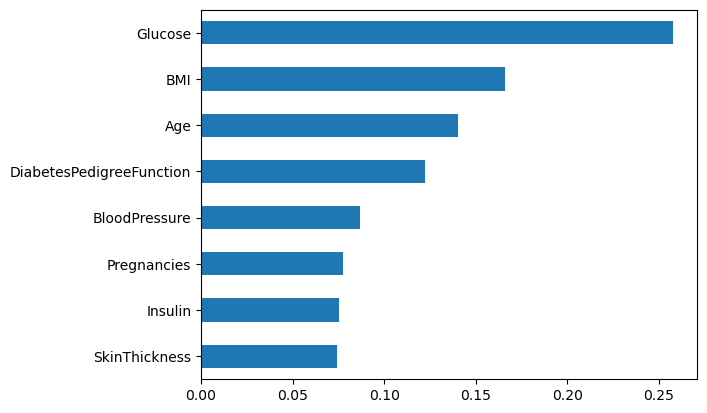

In [86]:

rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh')